In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Анализ навыков для сайта [hirify](https://hirify.me).

### Работа со skills

#### Работа с основным датасетом

In [3]:
data = pd.read_csv("vacancies_cleaned.csv")
data.sample(3)

,title,link,tags,company,skills,salary,relocation,employment_type,onsite,remote,hybrid,lead,c_level,senior,director,trainee,head,middle,junior,location
8537,Engineering Lead (Security),https://hirify.me/jobs/431645-engineering-lead...,"['remote (USA)', 'US', 'fulltime', 'lead']",Company hidden,"['ai', 'python', 'go', 'siem', 'bash', '+5 ski...",NaN,False,fulltime,True,False,True,True,False,False,False,False,False,False,False,US
5656,Operations Project Manager,https://hirify.me/jobs/434910-operations-proje...,"['hybrid', 'US', 'project']",Company hidden,"['project management', 'operations', 'document...",75 - 80\n$,False,project,True,True,False,False,False,False,False,False,False,False,False,US
2719,YouTube Producer,https://hirify.me/jobs/438539-youtube-producer,"['onsite', 'fulltime']",NaN,"['youtube', 'content strategy', 'blogging', 'b...",NaN,False,fulltime,False,True,True,False,False,False,False,False,False,False,False,NaN


Данные в колонке представлены строковым типом. для дальнейшей обработки преобразуем в массив с помощью функции: 

In [4]:
def str_to_list(skills_string):

    try:
        if not skills_string or skills_string == "[]":
            return []
        skills_string = skills_string[1:-1].split(",")
        skills_list = [
            skill.replace("'", "").strip().lower() for skill in skills_string
        ]
        skills_list = set(skills_list)
        return list(skills_list)

    except Exception:
        return []

In [5]:
data["skills"] = data["skills"].apply(lambda x: str_to_list(x))

Перед началом обработки определим дополнительный признак - количество требований вакансии.

Так в массивах навыков содержаться признаки вида `+x skills`, для определения корректного количества признаков используется функция: 

In [6]:
def get_correct_len(array):
    l = 0
    if array is None:
        return 0
    for value in array:
        if " skills" in value and value[0] == "+":
            l += int(value.split(" ")[0])
        else:
            l += 1
    return l

Оценим, как распределено количество требуемых инструментов для различных вакансий.

In [7]:
data["skills_num"] = data["skills"].apply(lambda x: get_correct_len(x))
skills_length_grouped = data["skills_num"].value_counts()
skills_length_grouped

skills_num
8     2241
7     2167
9     1639
6     1381
10    1017
5      725
11     328
4      323
3      170
12     136
2       82
13      72
14      68
1       53
15      39
16      31
17      24
18      13
22      10
19       9
20       9
21       4
24       3
28       2
0        1
30       1
32       1
34       1
27       1
26       1
25       1
Name: count, dtype: int64

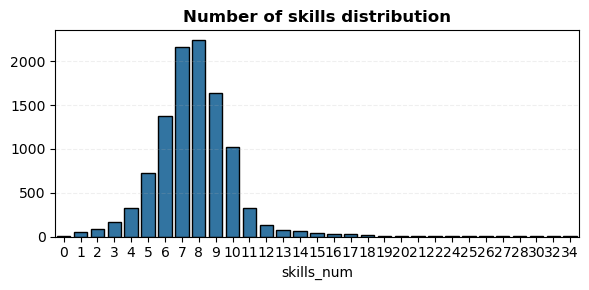

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    edgecolor="black",
)
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills distribution", fontweight="bold")
plt.tight_layout()

Большинство вакансий требуют от 5 до 10 навыков. При этом наблюдается сильный правый хвост распределения числа признаков.

Попробуем определить, какое среднее количество скиллов нужно каждому из грейдов: 

In [9]:
data.columns

Index(['title', 'link', 'tags', 'company', 'skills', 'salary', 'relocation',
       'employment_type', 'onsite', 'remote', 'hybrid', 'lead', 'c_level',
       'senior', 'director', 'trainee', 'head', 'middle', 'junior', 'location',
       'skills_num'],
      dtype='object')

In [10]:
grades = ["lead", "senior", "director", "head", "middle", "junior", "trainee"]
grades_avg = []
for grade in grades:
    grades_avg.append(data[data[grade]]["skills_num"].mean())
level_groupped = pd.Series(grades_avg, grades).sort_values()
level_groupped

trainee     6.697842
junior      7.028169
head        7.310204
director    7.641553
middle      7.845096
lead        8.230565
senior      8.333882
dtype: float64

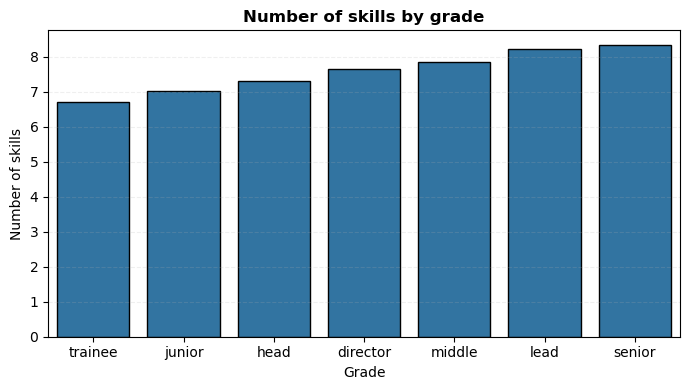

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=level_groupped, edgecolor="black")

ax.set_xlabel("Grade")
ax.set_ylabel("Number of skills")
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills by grade", fontweight="bold")
plt.tight_layout()

#### Создание расширенной таблицы

Для формирования дополнительного столбца используется метод [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html):

In [12]:
data_skills = (
    data.reset_index()[["index", "skills"]]
    .explode("skills")
    .rename(columns={"skills": "skill", "index": "id"})
)
data_skills

,id,skill
0,0,negotiation
0,0,sales
0,0,crm
0,0,saas
0,0,healthcare
...,...,...
10552,10552,sql
10552,10552,excel
10552,10552,kibana
10552,10552,databases


In [13]:
data_skills["skill"].value_counts().head(10)

skill
ai           3190
+3 skills    2241
+2 skills    2167
python       1718
+4 skills    1639
+1 skills    1381
+5 skills    1017
sql           979
saas          920
fintech       880
Name: count, dtype: int64

In [14]:
print(f"Наличе дубликатов:              {data_skills.duplicated().any()}")
print(f"Количество уникальных значений: {data_skills['skill'].nunique()}")
print(f"Количество пропусков:           {data_skills['skill'].isna().sum()}")

Наличе дубликатов:              False
Количество уникальных значений: 3609
Количество пропусков:           1


In [15]:
data_skills = data_skills.dropna()

In [16]:
data_skills[data_skills["skill"].str.contains("+", regex=False)] = "additional skills"

C:\Users\Anton\AppData\Local\Temp\ipykernel_448\2334453213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_skills[data_skills["skill"].str.contains("+", regex=False)] = "additional skills"
C:\Users\Anton\AppData\Local\Temp\ipykernel_448\2334453213.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'additional skills' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_skills[data_skills["skill"].str.contains("+", regex=False)] = "additional skills"


Для определения выражений с `+n skills` спользован метод работы со строками в датасетах pandas: [`.str.contains`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html).

In [17]:
data_skills["skill"].value_counts().head(10)

skill
additional skills    9520
ai                   3190
python               1718
sql                   979
saas                  920
fintech               880
russian               723
kubernetes            711
sales                 710
crm                   639
Name: count, dtype: int64

Определим самые часто-встречающиеся навыки. Не будем учитывать навыки, которые нам не известны и записаны как `additional skills`.

In [18]:
add_skills_mask = data_skills["skill"] == "additional skills"
print(
    f"Количество упоминаний additional skills в данных: {add_skills_mask.sum()} - {np.round(add_skills_mask.sum() / data_skills.shape[0] * 100, 2)}%"
)
data_skills_clean = data_skills[~add_skills_mask]

Количество упоминаний additional skills в данных: 9520 - 15.65%


In [19]:
top_n = 15
skill_stats = data_skills_clean["skill"].value_counts().head(top_n).sort_values()
skill_stats

skill
project management     462
b2b                    485
salesforce             496
docker                 507
typescript             509
english                522
crm                    639
sales                  710
kubernetes             711
russian                723
fintech                880
saas                   920
sql                    979
python                1718
ai                    3190
Name: count, dtype: int64

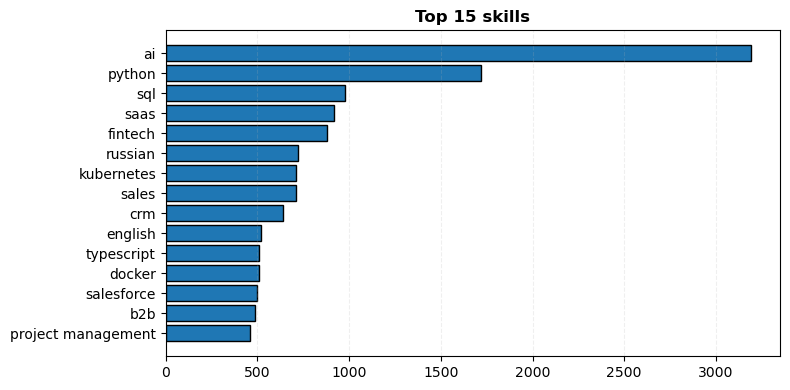

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(y=skill_stats.index, width=skill_stats.values, edgecolor="black")

ax.grid(axis="x", linestyle="--", alpha=0.2)
ax.set_title(f"Top {top_n} skills", fontweight="bold")
plt.tight_layout()

Определим топ скилов для каждого формата работы:
- `hybrid` - гибридный
- `remote` - удаленный
- `onsite` - в офисе

In [ ]:
data_skills_clean

,id,skill
0,0,negotiation
0,0,sales
0,0,crm
0,0,saas
0,0,healthcare
...,...,...
10552,10552,customer support
10552,10552,sql
10552,10552,excel
10552,10552,kibana


In [ ]:
top_n = 5
work_formats = ["onsite", "remote", "hybrid"]

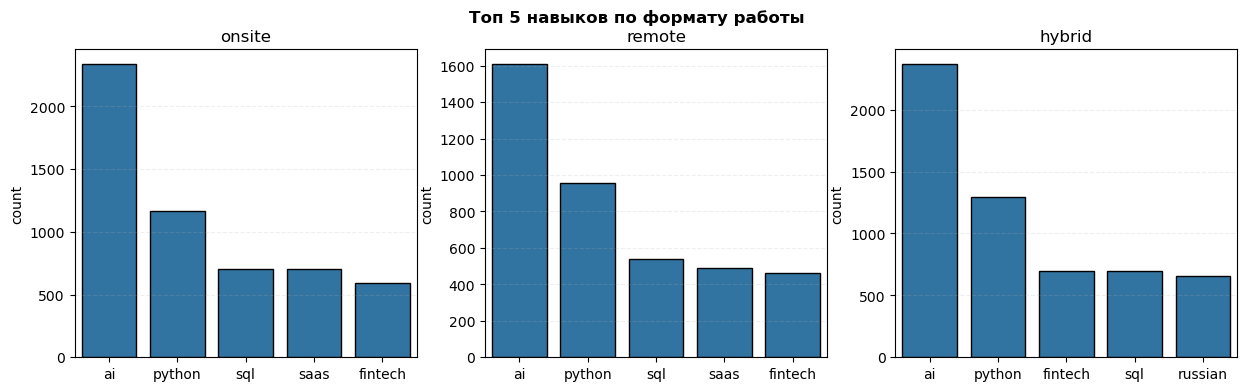

In [67]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
fig.suptitle("Топ 5 навыков по формату работы", fontweight="bold")

for i in range(3):
    data_selected = data[data[work_formats[i]]].join(data_skills_clean)
    data_selected_groupped = data_selected["skill"].value_counts().head(top_n)
    sns.barplot(data=data_selected_groupped, edgecolor="black", ax=axes[i])
    axes[i].set_title(work_formats[i])
    axes[i].set_xlabel("")
    axes[i].grid(axis="y", linestyle="--", alpha=0.2)